Understanding and coding with Python

Convolution: 1D operation with Python (Numpy/Scipy)
Mathematical notation
In this first example, we will use the pure mathematical notation. Here we have a one dimensional convolution operation. Lets say h is our image and x is our kernel:
x[i] = { 3, 4, 5 }
h[i] = { 2, 1, 0 }

where i = index

To use the convolution operation between the two arrays try the code below to see how easy it is to do in Python.


In [3]:
import numpy as np
x = np.array([3, 4, 5])
h = np.array([2, 1, 0])

y = np.convolve(x, h)
y

array([ 6, 11, 14,  5,  0])

In [ ]:
print("Compare with the following values from Python: y[0] = {0} ; y[1] = {1}; y[2] = {2}; y[3] = {3}; y[4] = {4}".format(y[0], y[1], y[2], y[3], y[4])) 

In [4]:
import numpy as np

x = [6, 2]
h = [1, 2, 5, 4]

y = np.convolve(x, h, "full")  #now, because of the zero padding, the final dimension of the array is bigger
y  

array([ 6, 14, 34, 34,  8])

In [5]:
import numpy as np

x = [6, 2]
h = [1, 2, 5, 4]

y = np.convolve(x, h, "same")  # it is same as zero padding, but with returns an ouput with the same length as max of x or h
y  

array([ 6, 14, 34, 34])

In [6]:
import numpy as np

x = [6, 2]
h = [1, 2, 5, 4]

y = np.convolve(x, h, "valid")   # valid returns output of length max(x, h) - min(x, h) + 1, this is to ensure that values outside of the boundary of 
                                # h will not be used in the calculation of the convolution
                                # in the next example we will understand why we used the argument valid
y  

array([14, 34, 34])

In [7]:
from scipy import signal as sg

I= [[255,   7,  3],
    [212, 240,  4],
    [218, 216, 230],]

g= [[-1, 1]]

print('Without zero padding \n')
print('{0} \n'.format(sg.convolve( I, g, 'valid')))
# The 'valid' argument states that the output consists only of those elements 
# that do not rely on the zero-padding.

print('With zero padding \n')
print(sg.convolve( I, g))

Without zero padding 

[[248   4]
 [-28 236]
 [  2 -14]] 

With zero padding 

[[-255  248    4    3]
 [-212  -28  236    4]
 [-218    2  -14  230]]


In [8]:
from scipy import signal as sg

I= [[255,   7,  3],
    [212, 240,  4],
    [218, 216, 230],]

g= [[-1,  1],
    [ 2,  3],]

print ('With zero padding \n')
print ('{0} \n'.format(sg.convolve( I, g, 'full')))
# The output is the full discrete linear convolution of the inputs. 
# It will use zero to complete the input matrix

print ('With zero padding_same_ \n')
print ('{0} \n'.format(sg.convolve( I, g, 'same')))
# The output is the full discrete linear convolution of the inputs. 
# It will use zero to complete the input matrix


print ('Without zero padding \n')
print (sg.convolve( I, g, 'valid'))
# The 'valid' argument states that the output consists only of those elements 
#that do not rely on the zero-padding.

With zero padding 

[[-255  248    4    3]
 [ 298  751  263   13]
 [ 206 1118  714  242]
 [ 436 1086 1108  690]] 

With zero padding_same_ 

[[-255  248    4]
 [ 298  751  263]
 [ 206 1118  714]] 

Without zero padding 

[[ 751  263]
 [1118  714]]


with TensorFlow

In [9]:
import tensorflow as tf
from IPython.display import Markdown, display

def printmd(string):
    display(Markdown('# <span style="color:red">'+string+'</span>'))


In [10]:
input = tf.Variable(tf.random.normal([1, 10, 10, 1]))
filter = tf.Variable(tf.random.normal([3, 3, 1, 1]))
op = tf.nn.conv2d(input, filter, strides=[1, 1, 1, 1], padding='VALID')
op2 = tf.nn.conv2d(input, filter, strides=[1, 1, 1, 1], padding='SAME')

print("Input \n")
print('{0} \n'.format(input.numpy()))
print("Filter/Kernel \n")
print('{0} \n'.format(filter.numpy()))
print("Result/Feature Map with valid positions \n")
print(op.numpy())
print('\n')
print("Result/Feature Map with padding \n")
print(op2.numpy())

Input 

[[[[ 1.6056887 ]
   [ 0.10238929]
   [-0.9255039 ]
   [-1.9676822 ]
   [-0.665485  ]
   [-1.6289788 ]
   [-2.4533505 ]
   [-0.5969938 ]
   [-1.1042446 ]
   [-1.3567202 ]]

  [[ 1.0318471 ]
   [ 0.3412714 ]
   [ 1.6999557 ]
   [ 0.6592275 ]
   [ 0.29460794]
   [ 0.33591905]
   [-1.1476985 ]
   [-0.01856813]
   [-1.9513268 ]
   [-0.02893584]]

  [[-1.5064725 ]
   [ 0.07403439]
   [-1.1390247 ]
   [-0.9550786 ]
   [ 0.3841618 ]
   [-0.5800449 ]
   [-0.18216485]
   [ 0.8393448 ]
   [-0.9301692 ]
   [-0.6103136 ]]

  [[-0.60598505]
   [ 0.29253265]
   [ 1.4948303 ]
   [ 1.5446147 ]
   [ 0.18101798]
   [ 1.6556543 ]
   [ 0.3763233 ]
   [ 1.3478751 ]
   [-1.9554747 ]
   [-2.1638966 ]]

  [[ 0.42758137]
   [ 0.82720274]
   [ 0.13618504]
   [ 0.12356327]
   [-0.612927  ]
   [-0.5581761 ]
   [-0.47286385]
   [-1.0641506 ]
   [-0.21301247]
   [-1.1016096 ]]

  [[ 0.60521346]
   [ 0.1923764 ]
   [ 1.321065  ]
   [ 0.6141971 ]
   [-1.9403447 ]
   [ 0.11529584]
   [ 1.4815077 ]
   [ 0.140579

In [14]:
from urllib.request import urlretrieve

urlretrieve(
    "https://ibm.box.com/shared/static/cn7yt7z10j8rx6um1v9seagpgmzzxnlz.jpg",
    "bird.jpg"
) 

('bird.jpg', <http.client.HTTPMessage at 0x1b5e8c22450>)

C:\Users\91962\AppData\Local\Temp\ipykernel_37312\783811109.py:3: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc



 Original type: <PIL.Image.Image image mode=L size=1920x1440 at 0x1B5E6F24550> 


After conversion to numerical representation: 

 array([[ 64,  71,  65, ...,  49,  47,  48],
       [ 68,  71,  64, ...,  54,  52,  51],
       [ 65,  69,  66, ...,  54,  50,  55],
       ...,
       [ 22,  23,  23, ..., 184, 170, 155],
       [ 18,  21,  26, ..., 179, 166, 153],
       [ 27,  22,  21, ..., 170, 159, 149]],
      shape=(1440, 1920), dtype=uint8)

 Input image converted to gray scale: 



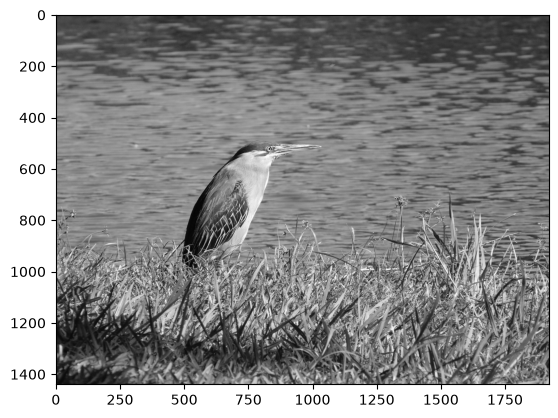

In [15]:
import numpy as np
from scipy import signal
from scipy import misc
import matplotlib.pyplot as plt
from PIL import Image

im = Image.open('bird.jpg')  # type here your image's name

image_gr = im.convert("L")    # convert("L") translate color images into black and white
                              # uses the ITU-R 601-2 Luma transform (there are several 
                              # ways to convert an image to grey scale)
print("\n Original type: %r \n\n" % image_gr)

# convert image to a matrix with values from 0 to 255 (uint8) 
arr = np.asarray(image_gr) 
print("After conversion to numerical representation: \n\n %r" % arr) 
### Activating matplotlib for Ipython
%matplotlib inline

### Plot image

imgplot = plt.imshow(arr)
imgplot.set_cmap('gray')  #you can experiment different colormaps (Greys,winter,autumn)
print("\n Input image converted to gray scale: \n")
plt.show(imgplot)

In [16]:
kernel = np.array([[ 0, 1, 0],
                   [ 1,-4, 1],
                   [ 0, 1, 0],]) 

grad = signal.convolve2d(arr, kernel, mode='same', boundary='symm')

GRADIENT MAGNITUDE - Feature map


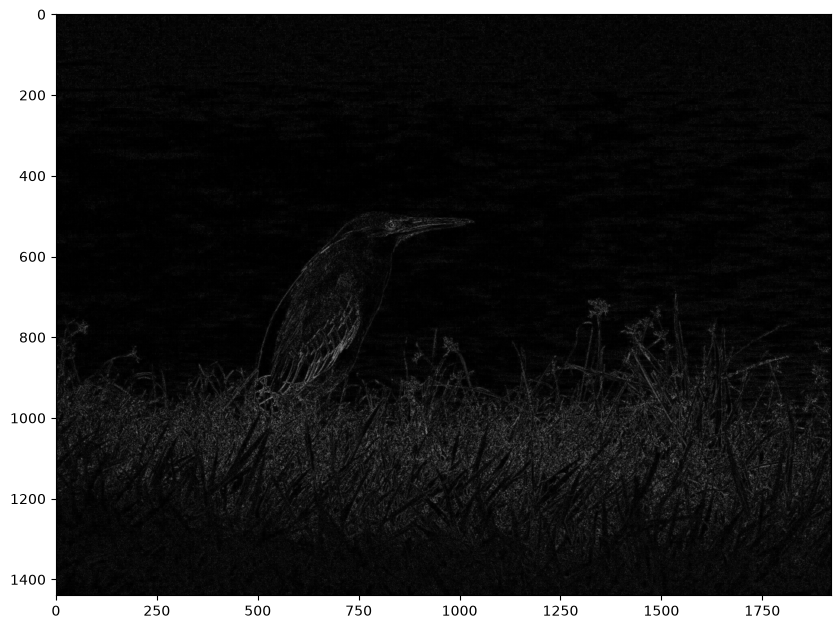

In [17]:
%matplotlib inline

print('GRADIENT MAGNITUDE - Feature map')

fig, aux = plt.subplots(figsize=(10, 10))
aux.imshow(np.absolute(grad), cmap='gray')

In [18]:
type(grad)

grad_biases = np.absolute(grad) + 100

grad_biases[grad_biases > 255] = 255

GRADIENT MAGNITUDE - Feature map


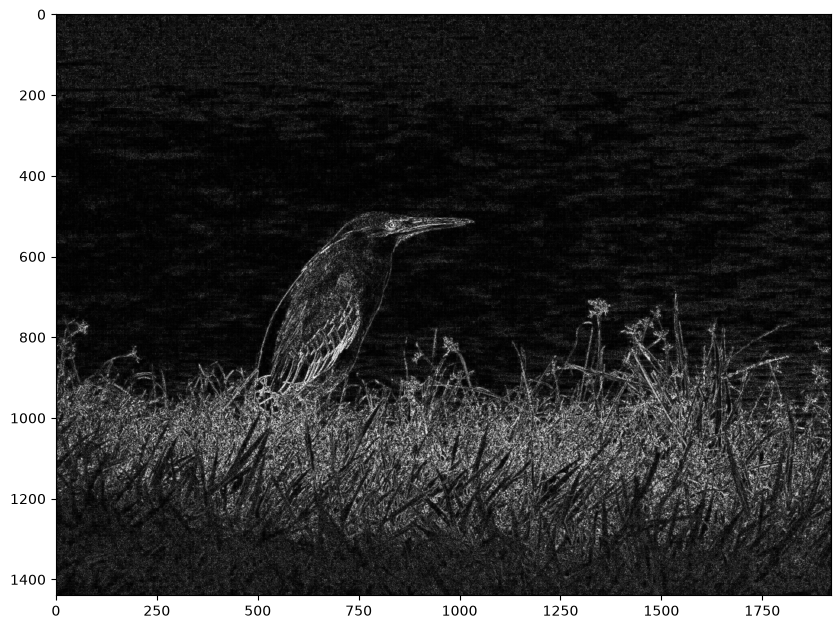

In [19]:
%matplotlib inline

print('GRADIENT MAGNITUDE - Feature map')

fig, aux = plt.subplots(figsize=(10, 10))
aux.imshow(np.absolute(grad_biases), cmap='gray')

In [ ]:
urlretrieve(
    "https://ibm.box.com/shared/static/vvm1b63uvuxq88vbw9znpwu5ol380mco.jpg",
    "num3.jpg"
) 

'wget' is not recognized as an internal or external command,
operable program or batch file.
